# Anatomy of a Phantom Edge: One Counter Breaks Your CV

A real, solvable task: forecast the mean benzene concentration over
the next three days from an hourly air-quality sensor. Data is the
UCI Air Quality set (an Italian city, 2004-2005) — real readings,
genuine daily structure, public, no key, ~1.5 MB. Cached in
`examples/data/` (git-ignored), offline after first run.

This notebook isolates *why* naive cross-validation lies. It runs
the same model twice:

- **standard features** — lag 1h, lag 24h, lag 168h.
- **standard + one innocuous extra** — a cumulative hour counter,
  the kind of feature people add without a second thought.

The 72-hour-mean label means neighbouring rows share 71 of 72 hours,
so their labels are almost identical. Add a monotone counter and a
shuffled split can walk straight from a test row to its near-twin in
training. Numbers below are the real run, reported as measured.

In [1]:
import urllib.request
import zipfile
from io import BytesIO
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neighbors import KNeighborsRegressor

from purgedcv import PurgedKFold, WalkForwardSplit
from purgedcv.diagnostics import compute_overlap_fraction

SEED = 0
H = 72  # label = mean concentration over the next 72 hours (3-day forecast)
N_SPLITS = 5

## Download and cache the sensor series

In [2]:
DATA_DIR = Path("data") if Path("data").exists() else Path("examples/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
cache = DATA_DIR / "air_quality_uci.csv"

if cache.exists():
    print(f"Using cached: {cache}")
    raw = pd.read_csv(cache)
else:
    url = "https://archive.ics.uci.edu/static/public/360/air+quality.zip"
    req = urllib.request.Request(url, headers={"User-Agent": "purgedcv-examples"})
    with urllib.request.urlopen(req, timeout=120) as r:
        z = zipfile.ZipFile(BytesIO(r.read()))
    with z.open("AirQualityUCI.csv") as fh:
        raw = pd.read_csv(fh, sep=";", decimal=",")
    raw = raw.dropna(axis=1, how="all").dropna(how="all")
    raw.to_csv(cache, index=False)
    print(f"Downloaded UCI Air Quality -> cached {cache}")

col = next(c for c in raw.columns if "C6H6" in c)  # benzene, ground truth
series = (
    pd.to_numeric(raw[col], errors="coerce").replace(-200, np.nan).interpolate().dropna().to_numpy()
)
print(f"{len(series)} hourly readings of benzene (C6H6)")

Downloaded UCI Air Quality -> cached data/air_quality_uci.csv
9357 hourly readings of benzene (C6H6)


## Features, label, and the one extra column

The label is the mean of the next 72 hours. Standard features are
three lags. The clock is just `0, 1, 2, ...` — a cumulative hour
index, perfectly innocent-looking.

In [3]:
n = len(series) - H
lag1 = series[:n]
lag24 = pd.Series(series).shift(24).to_numpy()[:n]
lag168 = pd.Series(series).shift(168).to_numpy()[:n]
clock = np.arange(n, dtype=float)  # cumulative hour counter
y = np.array([series[i + 1 : i + 1 + H].mean() for i in range(n)])

ok = np.isfinite(np.column_stack([lag1, lag24, lag168])).all(axis=1)
X_std = np.column_stack([lag1, lag24, lag168])[ok]
X_clk = np.column_stack([lag1, lag24, lag168, clock])[ok]
y = y[ok]
pred = pd.Series(pd.date_range("2004-03-10", periods=n, freq="h"))[ok]
pred = pred.reset_index(drop=True)
evalu = pred + pd.Timedelta(hours=H)
print(
    f"usable rows: {len(y)}  (real signal: corr(lag1, y) = {np.corrcoef(X_std[:, 0], y)[0, 1]:+.2f})"
)

usable rows: 9117  (real signal: corr(lag1, y) = +0.32)


## Same model, same splits — with and without the counter

`naive shuffled k-fold` vs `PurgedKFold` vs `WalkForwardSplit`, run
on the standard features and then on standard + the clock.

In [4]:
model = KNeighborsRegressor(n_neighbors=10)
naive = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
purged = PurgedKFold(
    n_splits=N_SPLITS,
    prediction_times=pred,
    evaluation_times=evalu,
    purge_horizon=f"{H}h",
    embargo=f"{H}h",
)
wf = WalkForwardSplit(
    n_splits=N_SPLITS,
    test_size=len(y) // 8,
    window="expanding",
    prediction_times=pred,
    evaluation_times=evalu,
    purge_horizon=f"{H}h",
)


def r2(feat, cv):
    return round(float(cross_val_score(model, feat, y, cv=cv, scoring="r2").mean()), 3)


rows = {
    "standard features": {
        "naive shuffled": r2(X_std, naive),
        "PurgedKFold": r2(X_std, purged),
        "WalkForward": r2(X_std, wf),
    },
    "+ one cumulative counter": {
        "naive shuffled": r2(X_clk, naive),
        "PurgedKFold": r2(X_clk, purged),
        "WalkForward": r2(X_clk, wf),
    },
}
pd.DataFrame(rows).T

,naive shuffled,PurgedKFold,WalkForward
standard features,0.073,-0.291,-0.521
+ one cumulative counter,0.991,-1.524,-0.814


In [5]:
ov_naive = np.mean([compute_overlap_fraction(tr, te, pred, evalu) for tr, te in naive.split(X_std)])
ov_purged = np.mean(
    [compute_overlap_fraction(tr, te, pred, evalu) for tr, te in purged.split(X_std)]
)
print(f"label overlap, naive shuffled : {ov_naive:.0%}")
print(f"label overlap, PurgedKFold    : {ov_purged:.0%}")

label overlap, naive shuffled : 100%
label overlap, PurgedKFold    : 0%


## The picture

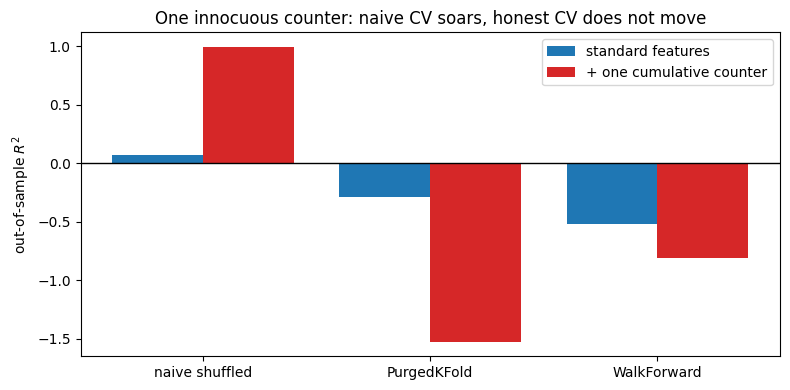

In [6]:
import matplotlib.pyplot as plt

schemes = ["naive shuffled", "PurgedKFold", "WalkForward"]
xs = np.arange(len(schemes))
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    xs - 0.2,
    [rows["standard features"][s] for s in schemes],
    0.4,
    label="standard features",
    color="#1f77b4",
)
ax.bar(
    xs + 0.2,
    [rows["+ one cumulative counter"][s] for s in schemes],
    0.4,
    label="+ one cumulative counter",
    color="#d62728",
)
ax.axhline(0.0, color="black", linewidth=1)
ax.set_xticks(xs, schemes)
ax.set_ylabel("out-of-sample $R^2$")
ax.set_title("One innocuous counter: naive CV soars, honest CV does not move")
ax.legend()
plt.tight_layout()
plt.show()

## Verdict

Read the table. With three ordinary lag features the model is weak:
naive shuffled k-fold says R-squared 0.07, the honest splits say it is
worse than the mean (-0.3 to -0.5). Real, and unremarkable.

Add one cumulative hour counter — a column anyone might add without
thinking — and naive shuffled k-fold reports R-squared 0.99. It looks
like a near-perfect three-day air-quality model. It is not. PurgedKFold
and WalkForward, on those very same features, stay firmly negative
(-1.52, -0.81). The model never improved. The counter just handed the
shuffled split a way to step from each test row to its near-twin in
training, whose 72-hour label is 71/72 identical.

That is the whole anatomy of a phantom edge: an innocuous monotone
feature, plus overlapping labels, plus a shuffled split. It is the same
failure as the OHLC and earthquake notebooks. The fix is not to ban
counters. It is to evaluate with a split that purges the overlap, which
keeps the score honest no matter what features you add.

If your CV score triples when you add a feature that has no business
predicting the future, the feature is not the problem and the model is
not the discovery. Your cross-validation is.

**Data:** UCI Machine Learning Repository, Air Quality (S. De Vito et
al.), CC BY 4.0.